### Explanations for the columns of the dataset

- `id`: Unique identifier for each record.
- `person_age`: Age of the individual, categorized into ranges.
- `person_income`: Income of the individual, categorized into income ranges.
- `person_home_ownership`: Homeownership status, which includes categories like 'RENT', 'MORTGAGE', etc.
- `person_emp_length`: Employment length of the individual, categorized into ranges based on years.
- `loan_intent`: The purpose of the loan, with categories such as 'EDUCATION', 'MEDICAL', etc.
- `loan_grade`: The credit grade of the loan, such as 'A', 'B', etc.
- `loan_amnt`: Loan amount, categorized into ranges.
- `loan_int_rate`: Loan interest rate, categorized into percentage ranges.
- `loan_percent_income`: Percentage of the individual’s income that the loan represents, categorized into - ranges.
- `cb_person_default_on_file`: Whether the person has a history of loan default, with values 'true' or 'false'.
- `cb_person_cred_hist_length`: Length of the individual’s credit history, categorized into ranges.
- `loan_status`: with values representing whether the loan status approval( binary values)

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Load in the train dataset
df_train = pd.read_csv('C:/Users/yasin.secal/Desktop/ysnscl/github/DSML/data/credit-loan/train.csv', index_col=0)
df_test = pd.read_csv('C:/Users/yasin.secal/Desktop/ysnscl/github/DSML/data/credit-loan/test.csv', index_col=0)

In [11]:
# Statistical summary of numerical columns
print(df_train[['person_age','person_income','loan_amnt']].describe())
print(df_test[['person_age','person_income','loan_amnt']].describe())

         person_age  person_income     loan_amnt
count  58645.000000   5.864500e+04  58645.000000
mean      27.550857   6.404617e+04   9217.556518
std        6.033216   3.793111e+04   5563.807384
min       20.000000   4.200000e+03    500.000000
25%       23.000000   4.200000e+04   5000.000000
50%       26.000000   5.800000e+04   8000.000000
75%       30.000000   7.560000e+04  12000.000000
max      123.000000   1.900000e+06  35000.000000
         person_age  person_income     loan_amnt
count  39098.000000   3.909800e+04  39098.000000
mean      27.566781   6.406046e+04   9251.466188
std        6.032761   3.795583e+04   5576.254680
min       20.000000   4.000000e+03    700.000000
25%       23.000000   4.200000e+04   5000.000000
50%       26.000000   5.800000e+04   8000.000000
75%       30.000000   7.588500e+04  12000.000000
max       94.000000   1.900000e+06  35000.000000


In [12]:
df_train.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

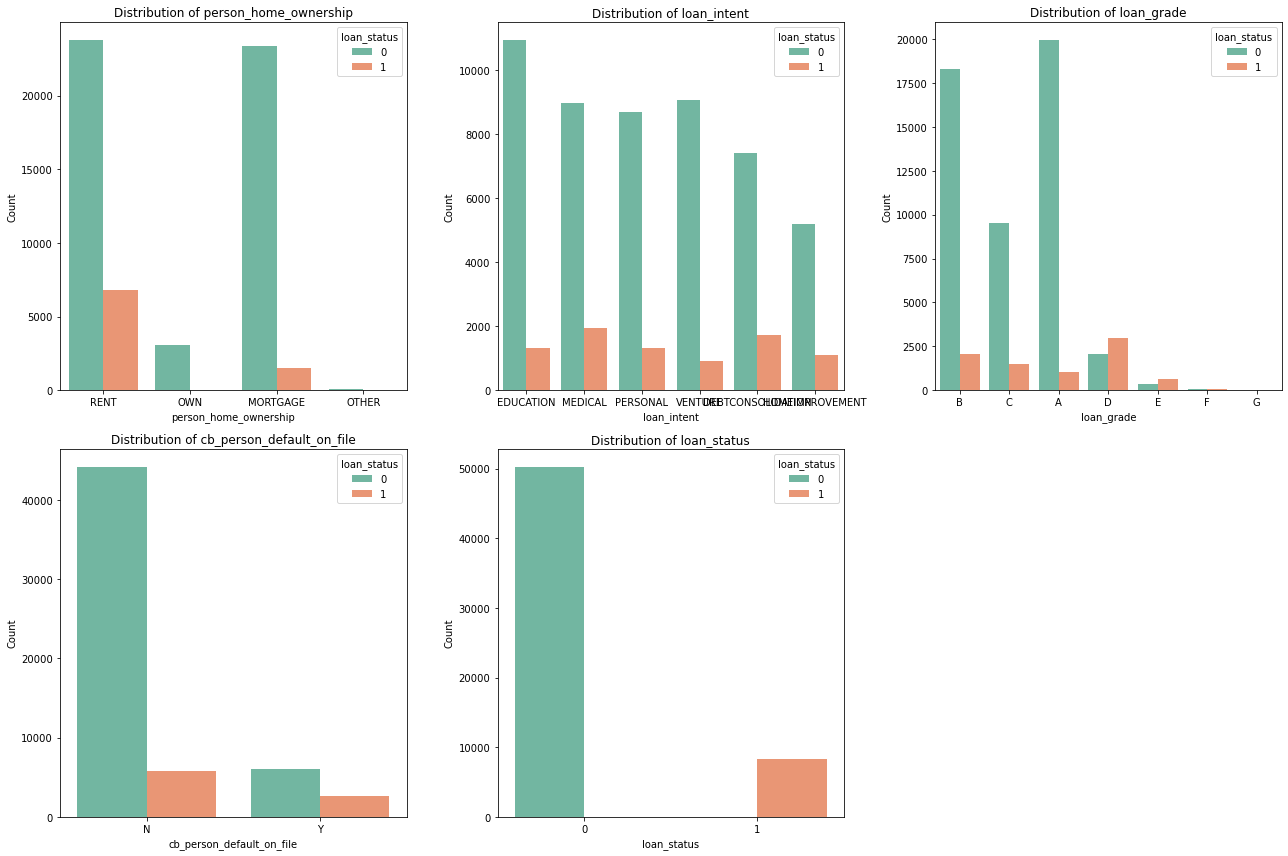

In [13]:
# List of categorical variables
categorical_vars = ['person_home_ownership', 'loan_intent', 'loan_grade',
                    'cb_person_default_on_file', 'loan_status']

# Number of variables
num_vars = len(categorical_vars)

# Calculate the number of rows and columns for subplots
cols = 3  # Number of columns
rows = (num_vars + cols - 1) // cols  # Calculate rows needed

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()  # Flatten the array of axes

# Plot each categorical variable
for i, var in enumerate(categorical_vars):
    sns.countplot(x=var, data=df_train, ax=axes[i], palette='Set2', hue='loan_status')
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Count')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

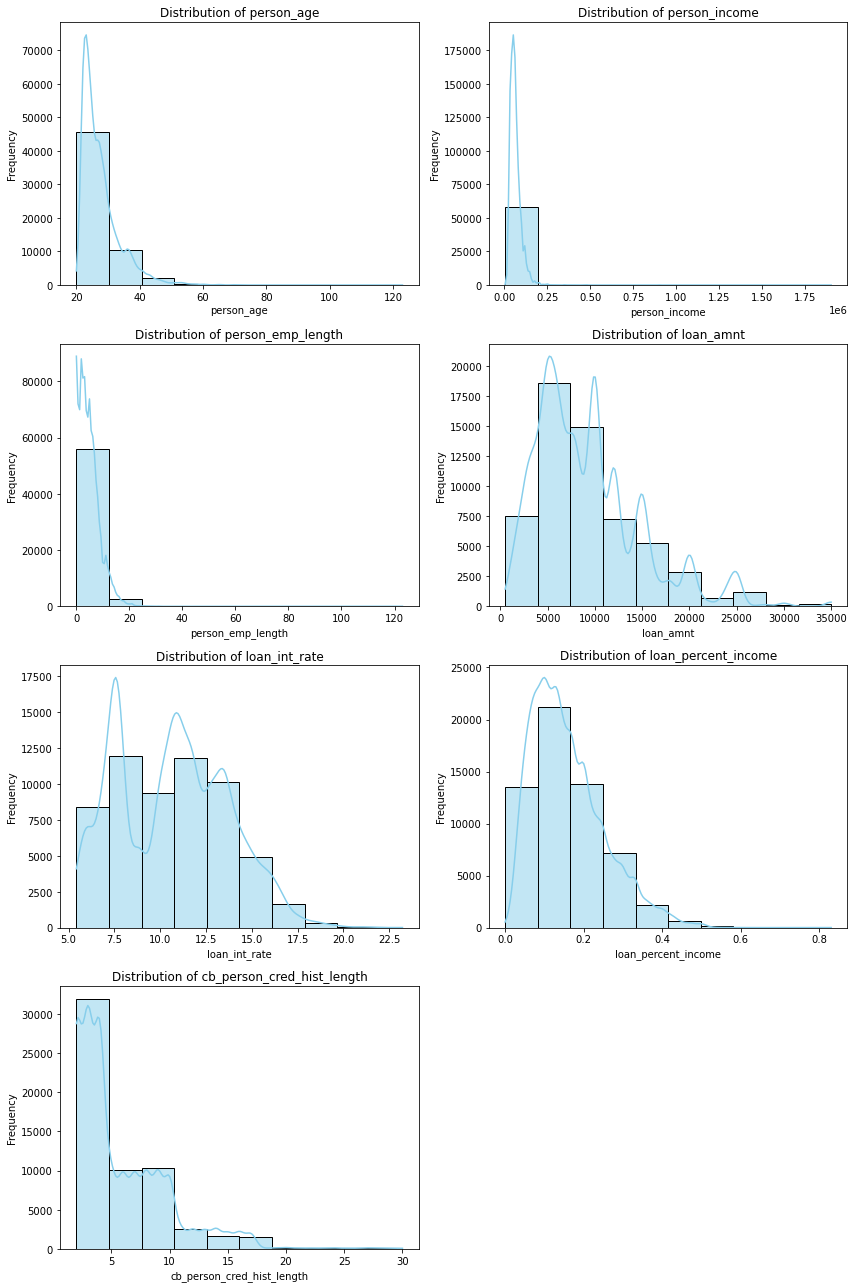

In [14]:
# List of numerical variables
numerical_vars = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                  'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

# Number of variables
num_vars = len(numerical_vars)

# Calculate the number of rows and columns for subplots
cols = 2  # Number of columns
rows = (num_vars + cols - 1) // cols  # Calculate rows needed

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, 18))
axes = axes.flatten()  # Flatten the array of axes


# Plot each numerical variable
for i, var in enumerate(numerical_vars):
    sns.histplot(df_train[var], kde=True, ax=axes[i], color='skyblue', bins=10)
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

In [15]:
# Create a copy of df_train to store data without outliers
df_cleaned = df_train.copy()

# List of numerical variables
numerical_vars = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                  'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

# Loop through each numerical variable to remove outliers
for var in numerical_vars:
    # Calculate Q1 and Q3
    Q1 = df_cleaned[var].quantile(0.25)
    Q3 = df_cleaned[var].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define the outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out the outliers
    df_cleaned = df_cleaned[(df_cleaned[var] >= lower_bound) & (df_cleaned[var] <= upper_bound)]

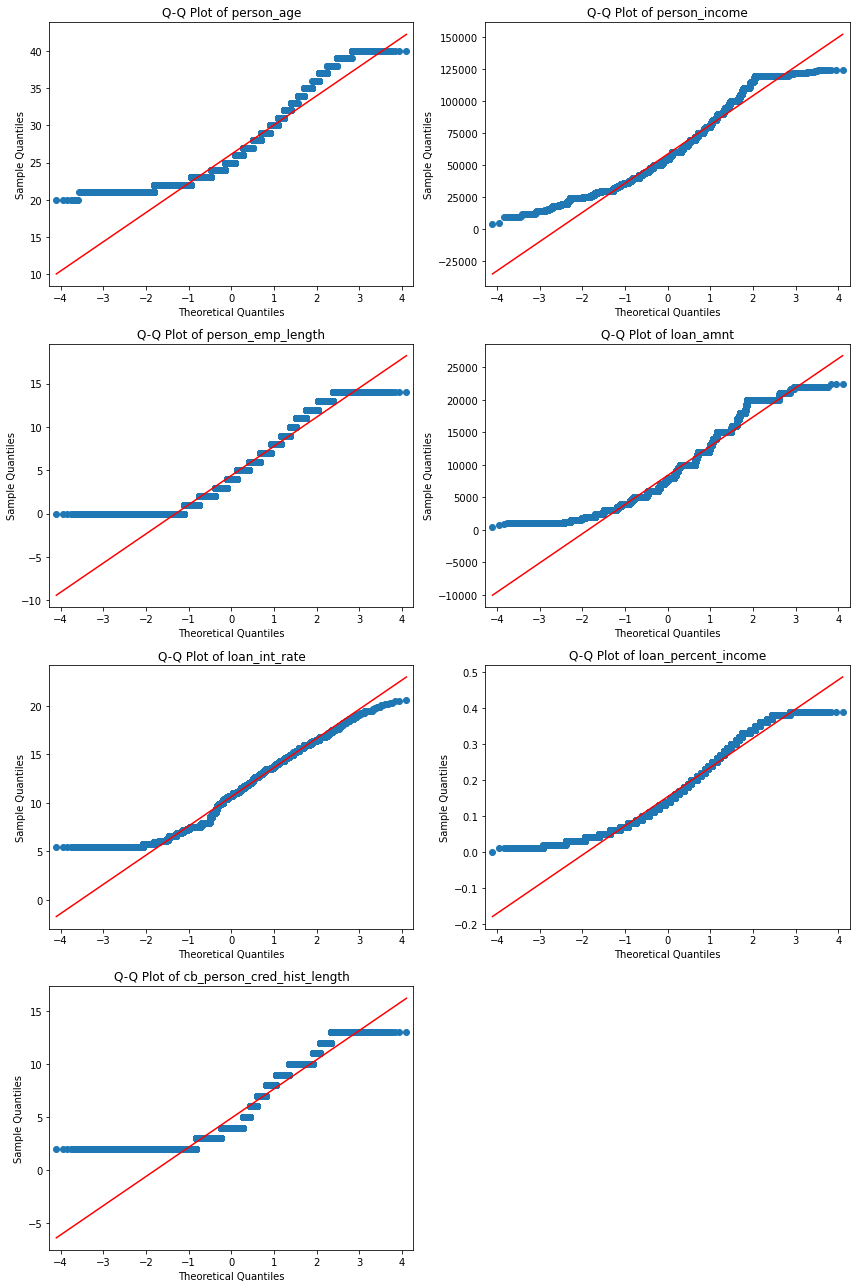

In [17]:
# Import statsmodels for Q-Q plots
import statsmodels.api as sm

# Create subplots for Q-Q plots
fig, axes = plt.subplots(rows, cols, figsize=(12, 18))
axes = axes.flatten()

# Plot Q-Q plots for each numerical variable
for i, var in enumerate(numerical_vars):
    sm.qqplot(df_cleaned[var], line='s', ax=axes[i])
    axes[i].set_title(f'Q-Q Plot of {var}')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

In [18]:
# One Hot Encoding
df_encoded = df_cleaned.copy()

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

df_encoded = pd.get_dummies(df_encoded,columns=categorical_cols)

In [20]:
# Calculate the correlation matrix
corr_matrix = df_encoded.corr()

# Extract the correlation of loan_status with other variables take the absolute value
loan_status_corr = corr_matrix['loan_status'].sort_values(ascending=False).apply(abs)

# Display the correlations
print("Correlation of loan_status with other variables:")
print(loan_status_corr)

Correlation of loan_status with other variables:
loan_status                       1.000000
loan_grade_D                      0.418257
loan_int_rate                     0.344195
loan_percent_income               0.302228
person_home_ownership_RENT        0.206566
loan_grade_E                      0.196129
cb_person_default_on_file_Y       0.195968
loan_amnt                         0.101633
loan_grade_F                      0.064092
loan_intent_DEBTCONSOLIDATION     0.056826
loan_intent_HOMEIMPROVEMENT       0.046327
loan_intent_MEDICAL               0.043970
loan_grade_G                      0.033045
person_home_ownership_OTHER       0.005250
loan_grade_C                      0.007838
person_age                        0.008931
loan_intent_PERSONAL              0.009535
cb_person_cred_hist_length        0.013908
loan_intent_EDUCATION             0.056502
loan_intent_VENTURE               0.066515
person_home_ownership_OWN         0.082646
loan_grade_B                      0.091454
perso

In [21]:
from sklearn.linear_model import LogisticRegression

X = df_encoded.drop(['loan_status'], axis=1)
y = df_encoded['loan_status']

# Initialize the logistic regression model
logreg = LogisticRegression()

# Fit the model
logreg.fit(X, y)

# Create a DataFrame to display coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': logreg.coef_[0]})

# Display the coefficients
coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
3,loan_amnt,1.573578e-04
4,loan_int_rate,2.857582e-07
20,loan_grade_D,3.743707e-08
25,cb_person_default_on_file_Y,2.181236e-08
10,person_home_ownership_RENT,2.001835e-08
21,loan_grade_E,8.112495e-09
13,loan_intent_HOMEIMPROVEMENT,6.992258e-09
11,loan_intent_DEBTCONSOLIDATION,6.793958e-09
5,loan_percent_income,3.375814e-09
14,loan_intent_MEDICAL,2.363572e-09


In [22]:
df = pd.concat([df_cleaned,df_test])

In [24]:
df_encoded = df.copy()

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

df_encoded = pd.get_dummies(df_encoded,columns=categorical_cols)

In [27]:
df_test2 = df_encoded[df_encoded.loan_status.isna()]
df_train2 = df_encoded[~df_encoded.loan_status.isna()]

In [30]:
from sklearn.model_selection import train_test_split

X = df_train2.drop(columns=["loan_status"])
y = df_train2["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.preprocessing import StandardScaler

# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
X_test_scaled

array([[ 0.72468869,  0.71729203, -0.11873641, ..., -0.01432726,
         0.41592777, -0.41592777],
       [-1.30623189, -0.37982228, -0.71163513, ..., -0.01432726,
         0.41592777, -0.41592777],
       [-0.54463667, -0.46759142,  1.06706104, ..., -0.01432726,
         0.41592777, -0.41592777],
       ...,
       [-0.54463667, -0.16039941, -0.41518577, ..., -0.01432726,
         0.41592777, -0.41592777],
       [ 0.21695854,  1.94588451,  1.36351041, ..., -0.01432726,
         0.41592777, -0.41592777],
       [ 0.47082362, -0.21323644, -0.71163513, ..., -0.01432726,
         0.41592777, -0.41592777]])

In [36]:
from sklearn.linear_model import LogisticRegression


# Initialize the logistic regression model
logreg = LogisticRegression()

# Fit the model
logreg.fit(X_train_scaled, y_train)

# Create a DataFrame to display coefficients
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': logreg.coef_[0]})

# Display the coefficients
coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
5,loan_percent_income,1.268212
20,loan_grade_D,0.659655
4,loan_int_rate,0.399502
10,person_home_ownership_RENT,0.359108
21,loan_grade_E,0.287286
13,loan_intent_HOMEIMPROVEMENT,0.214256
11,loan_intent_DEBTCONSOLIDATION,0.179848
14,loan_intent_MEDICAL,0.102583
22,loan_grade_F,0.087042
8,person_home_ownership_OTHER,0.034291


In [37]:
from sklearn.metrics import accuracy_score
y_pred = logreg.predict(X_test_scaled)
accuracy_score(y_test,y_pred)

0.9125795198029961

In [39]:
from sklearn.metrics import roc_auc_score
y_pred_probs = logreg.predict_proba(X_test_scaled)[:, 1]
print('roc_auc_score:', roc_auc_score(y_test, y_pred_probs))
print('gini score:', 2*roc_auc_score(y_test, y_pred_probs)-1)

roc_auc_score: 0.9005441139192657
gini score: 0.8010882278385314


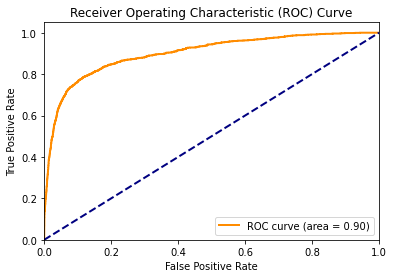

In [40]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [42]:
from xgboost import XGBClassifier
import optuna

In [43]:
import optuna
from xgboost import XGBClassifier
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.01, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'alpha': trial.suggest_float('alpha', 0, 10),
        'lambda': trial.suggest_float('lambda', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10)
    }
    
    model = XGBClassifier(**params, objective="binary:logistic",eval_metric="logloss")
    
    # Perform k-fold cross-validation
    #cv_scores = cross_val_score(model, X, y, cv=3, scoring='accuracy')
    # Train Test Split
    X_train2, X_test2, y_train2, y_test2 = train_test_split(X_train,y_train, test_size=0.2, random_state=42)
    model.fit(X_train2, y_train2)
    y_pred = model.predict(X_test2)
    # Calculate gini score
    accuracy = accuracy_score(y_test2, y_pred)
    
    # Return the mean cross-validation score
    return accuracy

# Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

# Best parameters
best_params = study.best_params
print('Best parameters:', best_params)

# Best score
best_score = study.best_value
print('Best accuracy score:', best_score)

[I 2024-10-28 15:23:41,939] A new study created in memory with name: no-name-b15388a1-15be-4f87-8bca-45a6a76c4ed7
c:\Users\yasin.secal\Anaconda3\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
c:\Users\yasin.secal\Anaconda3\lib\site-packages\xgboost\data.py:208: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
[I 2024-10-28 15:23:48,198] Trial 0 finished with value: 0.9268949595998461 and parameters: {'n_estimators': 158, 'max_depth': 12, 'learning_rate': 0.242012868

Best parameters: {'n_estimators': 223, 'max_depth': 18, 'learning_rate': 0.28343165227868816, 'subsample': 0.5893028200269775, 'colsample_bytree': 0.805031223587442, 'min_child_weight': 3, 'gamma': 0.5360020873147828, 'alpha': 6.973419171682174, 'lambda': 8.057391340007802, 'scale_pos_weight': 1.264284484001144}
Best accuracy score: 0.9481851994356804


In [44]:
best_model = XGBClassifier(**best_params,objective="binary:logistic",eval_metric="logloss")
best_model.fit(X_train,y_train)

y_pred = best_model.predict(X_test)

accuracy_score(y_test,y_pred)

c:\Users\yasin.secal\Anaconda3\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
c:\Users\yasin.secal\Anaconda3\lib\site-packages\xgboost\data.py:208: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


0.9508516314385389

In [45]:
from sklearn.metrics import roc_auc_score
y_pred_probs = best_model.predict_proba(X_test)[:, 1]
print('roc_auc_score:', roc_auc_score(y_test, y_pred_probs))
print('gini score:', 2*roc_auc_score(y_test, y_pred_probs)-1)

roc_auc_score: 0.9495702345004248
gini score: 0.8991404690008495


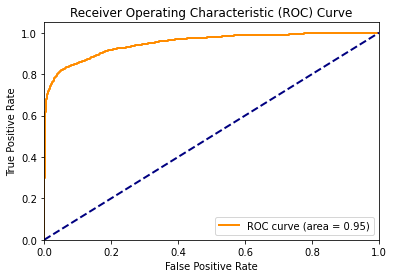

In [46]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [50]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [51]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      8472
         1.0       0.87      0.73      0.80      1274

    accuracy                           0.95      9746
   macro avg       0.92      0.86      0.88      9746
weighted avg       0.95      0.95      0.95      9746

[[8337  135]
 [ 344  930]]


In [55]:
X_train.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_A',
       'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E',
       'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_N',
       'cb_person_default_on_file_Y'],
      dtype='object')

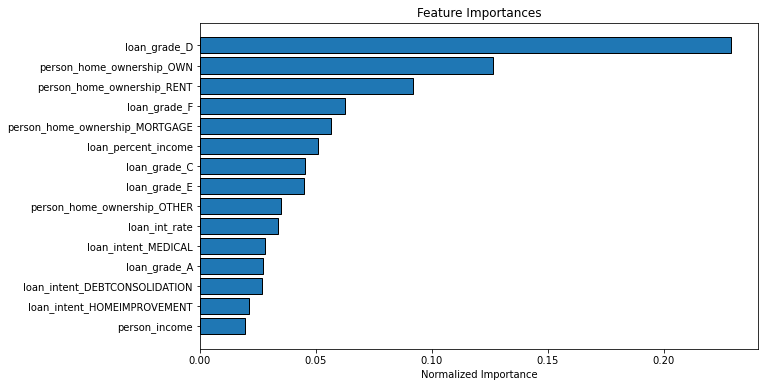

In [56]:
 # Feature Importance
# Get feature importances
feature_importance = best_model.feature_importances_
feature_names = X_train.columns

# Create a dataframe of feature importances
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
})

    # Sort features according to importance
df = feature_importance_df.sort_values('importance', ascending = False).reset_index()

# Normalize the feature importances to add up to one
df['importance_normalized'] = df['importance'] / df['importance'].sum()
# Make a horizontal bar chart of feature importances
plt.figure(figsize = (10, 6))
ax = plt.subplot()

# Need to reverse the index to plot most important on top
ax.barh(list(reversed(list(df.index[:15]))), 
        df['importance_normalized'].head(15), 
        align = 'center', edgecolor = 'k')

# Set the yticks and labels
ax.set_yticks(list(reversed(list(df.index[:15]))))
ax.set_yticklabels(df['feature'].head(15))

# Plot labeling
plt.xlabel('Normalized Importance'); plt.title('Feature Importances')
plt.show()